# SECOM: подготовка данных, EDA и выбор модели

Датасет: [UCI Machine Learning Repository, SECOM](https://archive.ics.uci.edu/dataset/179/secom).

Локальные файлы:

- `C:/Users/shega/Documents/GitHub/ML_coursework_2026/data/secom.data` - матрица сенсорных измерений;
- `C:/Users/shega/Documents/GitHub/ML_coursework_2026/data/secom_labels.data` - целевая метка и timestamp;
- `C:/Users/shega/Documents/GitHub/ML_coursework_2026/data/secom.names` - локальное описание датасета.

Цель notebook - подготовить сырой набор данных, описать preprocessing и feature engineering, провести разведочный анализ, сформулировать 3-5 ML-гипотез и выбрать лучшую модель с учетом сильного дисбаланса классов.


## 1. Сырые данные: что включаем в анализ

В анализ включаются все строки из `secom.data` и соответствующие строки из `secom_labels.data`. Каждая запись соответствует одной производственной единице в процессе выпуска полупроводников, а признаки являются анонимизированными вещественными измерениями сенсоров или контрольных точек процесса.

Используемые поля:

- все исходные сенсорные признаки из `secom.data`, потому что признаки анонимизированы и заранее исключать технологические точки без предметной расшифровки рискованно;
- целевая метка из `secom_labels.data`: `-1` означает `Pass`, `1` означает `Fail`;
- timestamp сохраняется для контроля периода наблюдений и потенциальной диагностики технологического дрейфа, но не используется как основной входной признак модели, чтобы не обучить модель на календарном артефакте.

Особенность задачи: `Fail` - редкое, но критичное событие. Поэтому обычная accuracy не подходит как основной критерий: модель, которая всегда предсказывает `Pass`, будет иметь высокую accuracy, но нулевой recall для брака.


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 20260430
DATA_PATH = Path("C:/Users/shega/Documents/GitHub/ML_coursework_2026/data/secom.data")
LABELS_PATH = Path("C:/Users/shega/Documents/GitHub/ML_coursework_2026/data/secom_labels.data")
NAMES_PATH = Path("C:/Users/shega/Documents/GitHub/ML_coursework_2026/data/secom.names")

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)


C:\Users\shega\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.sparse import csr_matrix, issparse


In [2]:
def load_secom(data_path: Path = DATA_PATH, labels_path: Path = LABELS_PATH):
    """Load SECOM features and labels.

    target_original: original UCI label, where -1 = Pass and 1 = Fail.
    target: binary ML label, where 0 = Pass and 1 = Fail.
    """
    x = pd.read_csv(data_path, sep=r"\s+", header=None, na_values=["NaN"], engine="python")
    x.columns = [f"sensor_{i:03d}" for i in range(x.shape[1])]

    rows = []
    pattern = re.compile(r'^\s*(-?1)\s+"([^"]+)"\s*$')
    for line in labels_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        match = pattern.match(line)
        if match is None:
            raise ValueError(f"Cannot parse label line: {line}")
        original_label = int(match.group(1))
        rows.append({
            "target_original": original_label,
            "target": 1 if original_label == 1 else 0,
            "timestamp": pd.to_datetime(match.group(2), format="%d/%m/%Y %H:%M:%S"),
        })

    labels = pd.DataFrame(rows)
    if len(x) != len(labels):
        raise ValueError(f"Feature rows ({len(x)}) do not match label rows ({len(labels)}).")
    return x, labels["target"], labels

X_raw, y, labels = load_secom()

print("X shape:", X_raw.shape)
print("labels shape:", labels.shape)
print("target counts:")
print(labels["target_original"].value_counts().sort_index())
print("time range:", labels["timestamp"].min(), "--", labels["timestamp"].max())
print("duplicated feature rows:", int(X_raw.duplicated().sum()))


X shape: (1567, 590)
labels shape: (1567, 3)
target counts:
target_original
-1    1463
 1     104
Name: count, dtype: int64
time range: 2008-07-19 11:55:00 -- 2008-10-17 06:07:00
duplicated feature rows: 0


In [3]:
summary = pd.DataFrame({
    "value": [
        X_raw.shape[0],
        X_raw.shape[1],
        int(y.sum()),
        int((y == 0).sum()),
        y.mean(),
        X_raw.isna().sum().sum(),
        X_raw.isna().mean().mean(),
        int((X_raw.nunique(dropna=True) <= 1).sum()),
        int(X_raw.duplicated().sum()),
    ]
}, index=[
    "n_objects",
    "n_sensor_features",
    "n_fail",
    "n_pass",
    "fail_rate",
    "total_missing_values",
    "overall_missing_rate",
    "constant_or_single_value_features",
    "duplicate_feature_rows",
])
summary


,value
n_objects,1567.0000
n_sensor_features,590.0000
n_fail,104.0000
n_pass,1463.0000
fail_rate,0.0664
total_missing_values,41951.0000
overall_missing_rate,0.0454
constant_or_single_value_features,116.0000
duplicate_feature_rows,0.0000


## 2. Предобработка данных: что используем и почему

Рекомендуемый preprocessing:

- Проверка консистентности: число строк в признаках и метках должно совпадать; timestamp должен корректно парситься; дубликаты и константные признаки нужно явно проверить.
- Обработка пропусков: признаки с очень большой долей пропусков удаляются внутри обучающего fold, остальные значения заполняются медианой. Медиана устойчивее среднего при выбросах, а пересчет внутри fold предотвращает утечку данных.
- Удаление артефактов: константные и почти константные признаки удаляются через `VarianceThreshold`, потому что они не несут информации для классификации и мешают статистическим тестам.
- Нормализация: `StandardScaler`, так как сенсорные признаки имеют разные масштабы; это особенно важно для логистической регрессии, KNN, PCA и отбора признаков.
- Дискретизация: не используется как обязательный шаг для основной модели, потому что она может потерять полезную числовую информацию. Пороговые правила лучше строить отдельно интерпретируемыми деревьями после выбора модели.
- Дисбаланс классов: используем стратифицированное разбиение, метрики `balanced_accuracy`, `recall_fail`, `f1_fail`, `average_precision`, веса классов `class_weight='balanced'` там, где модель это поддерживает, и настройку порога вероятности для класса `Fail`.


In [4]:
missing_table = pd.DataFrame({
    "missing_count": X_raw.isna().sum(),
    "missing_rate": X_raw.isna().mean(),
    "n_unique": X_raw.nunique(dropna=True),
}).sort_values("missing_rate", ascending=False)

print("features with missing values:", int((missing_table["missing_count"] > 0).sum()))
print("features with >50% missing:", int((missing_table["missing_rate"] > 0.50).sum()))
missing_table.head(20)


features with missing values: 538
features with >50% missing: 28


,missing_count,missing_rate,n_unique
sensor_157,1429,0.9119,128
sensor_292,1429,0.9119,92
sensor_293,1429,0.9119,138
sensor_158,1429,0.9119,138
sensor_492,1341,0.8558,226
sensor_358,1341,0.8558,20
sensor_220,1341,0.8558,69
sensor_085,1341,0.8558,97
sensor_517,1018,0.6496,543
sensor_518,1018,0.6496,542


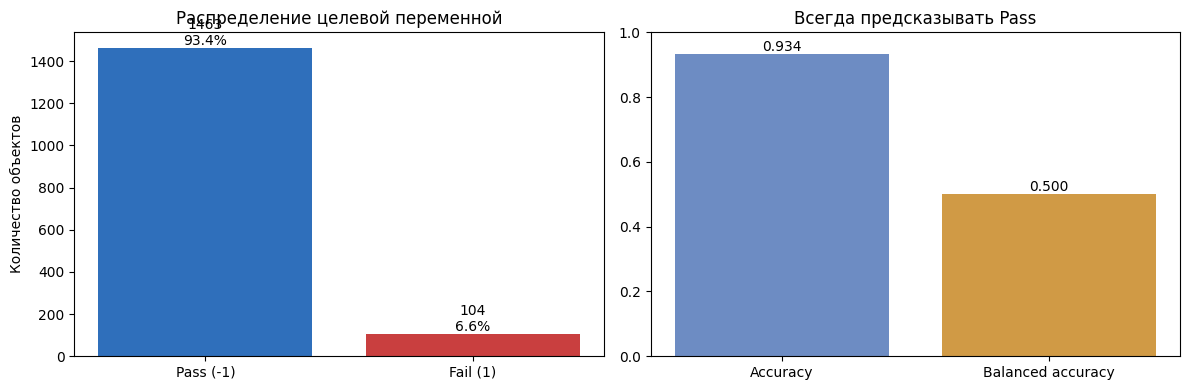

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y.map({0: "Pass (-1)", 1: "Fail (1)"}).value_counts().reindex(["Pass (-1)", "Fail (1)"])
axes[0].bar(counts.index, counts.values, color=["#2f6fbb", "#c93f3f"])
axes[0].set_title("Распределение целевой переменной")
axes[0].set_ylabel("Количество объектов")
for i, value in enumerate(counts.values):
    axes[0].text(i, value, f"{value}\n{value / len(y):.1%}", ha="center", va="bottom")

baseline_acc = accuracy_score(y, np.zeros_like(y))
baseline_bal_acc = balanced_accuracy_score(y, np.zeros_like(y))
axes[1].bar(["Accuracy", "Balanced accuracy"], [baseline_acc, baseline_bal_acc], color=["#6d8cc3", "#d09a45"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Всегда предсказывать Pass")
for i, value in enumerate([baseline_acc, baseline_bal_acc]):
    axes[1].text(i, value, f"{value:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


### Почему baseline `always Pass` имеет 93.4% accuracy

Если оптимизировать только обычную accuracy, то для этого датасета действительно очень сильным baseline оказывается правило `всегда Pass`: оно получает примерно 93.4% accuracy, потому что `Fail` встречается редко. Но такая модель не решает задачу контроля качества: она не находит ни одного дефектного объекта, поэтому `Recall Fail = 0`, а `Balanced Accuracy = 0.5`.

В этом проекте модель с меньшей accuracy может быть лучше по смыслу задачи, если она находит часть `Fail`. Плата за это - ложные тревоги, то есть часть нормальных объектов получает прогноз `Fail`. Поэтому основной критерий должен быть не `accuracy`, а `Balanced Accuracy`, `BER = 1 - Balanced Accuracy`, `Recall Fail`, `F1 Fail`, `PR-AUC` или явно заданная бизнес-стоимость ошибок. Если преподаватель или постановка задачи требуют именно максимизировать accuracy, честный вывод будет таким: тривиальное правило `always Pass` почти невозможно побить без потери чувствительности к редкому классу.


In [6]:
def binary_metrics(y_true, y_pred):
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": bal_acc,
        "ber": 1 - bal_acc,
        "recall_fail": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_fail": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fail": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

baseline_table = pd.DataFrame([
    {"strategy": "always_pass", **binary_metrics(y, np.zeros_like(y))},
    {"strategy": "always_fail", **binary_metrics(y, np.ones_like(y))},
])
baseline_table


,strategy,accuracy,balanced_accuracy,ber,recall_fail,precision_fail,f1_fail
0,always_pass,0.9336,0.5,0.5,0.0,0.0000,0.0000
1,always_fail,0.0664,0.5,0.5,1.0,0.0664,0.1245


## 3. Feature engineering и снижение размерности

Для SECOM одновременно важны интерпретируемость и устойчивость к шуму, поэтому в основной модели используются:

- row-level missingness: `missing_count` и `missing_rate` как признаки качества/полноты измерений;
- интегральные показатели отклонения объекта от типичного состояния: `mean_abs_z` и `max_abs_z`;
- фильтрация признаков с высокой долей пропусков;
- `VarianceThreshold` для удаления констант;
- `SelectKBest(f_classif)` как supervised отбор значимых признаков, где `k` подбирается вместе с моделью.

PCA добавлена как диагностическая визуализация структуры данных, но не выбрана основным способом для итоговой модели: главная причина - потеря прямой интерпретации анонимизированных сенсоров.


In [7]:
def cohen_d(pass_values: pd.Series, fail_values: pd.Series) -> float:
    a = pass_values.dropna().to_numpy(dtype=float)
    b = fail_values.dropna().to_numpy(dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a) - 1) * np.var(a, ddof=1) + (len(b) - 1) * np.var(b, ddof=1)) / (len(a) + len(b) - 2)
    if pooled_var <= 1e-12:
        return np.nan
    return float((np.mean(b) - np.mean(a)) / np.sqrt(pooled_var))

def compute_feature_statistics(x: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    rows = []
    pass_mask = y == 0
    fail_mask = y == 1
    for col in x.columns:
        values = x[col]
        d = cohen_d(values[pass_mask], values[fail_mask])
        rows.append({
            "feature": col,
            "missing_count": int(values.isna().sum()),
            "missing_rate": float(values.isna().mean()),
            "mean": float(values.mean(skipna=True)),
            "std": float(values.std(skipna=True)),
            "min": float(values.min(skipna=True)),
            "q25": float(values.quantile(0.25)),
            "median": float(values.median(skipna=True)),
            "q75": float(values.quantile(0.75)),
            "max": float(values.max(skipna=True)),
            "pass_mean": float(values[pass_mask].mean(skipna=True)),
            "fail_mean": float(values[fail_mask].mean(skipna=True)),
            "cohen_signed": d,
            "cohen_abs": abs(d) if np.isfinite(d) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("cohen_abs", ascending=False, na_position="last")

feature_stats = compute_feature_statistics(X_raw, y)
top5_features = feature_stats.head(5)["feature"].tolist()
feature_stats.head(10)


,feature,missing_count,missing_rate,mean,std,min,q25,median,q75,max,pass_mean,fail_mean,cohen_signed,cohen_abs
59,sensor_059,7,0.0045,2.9602,9.5322,-28.9882,-1.8716,0.9472,4.3852,168.1455,2.5635,8.5151,0.6319,0.6319
103,sensor_103,2,0.0013,-0.0098,0.0031,-0.0329,-0.0118,-0.0101,-0.0082,0.0203,-0.0099,-0.0081,0.6137,0.6137
510,sensor_510,2,0.0013,55.7635,37.6917,0.0000,35.3222,46.9861,64.2487,451.4851,54.4406,74.3479,0.5326,0.5326
348,sensor_348,24,0.0153,0.0247,0.0119,0.0103,0.0180,0.0226,0.0273,0.2200,0.0243,0.0304,0.5233,0.5233
158,sensor_158,1429,0.9119,1039.6507,406.8488,234.0996,721.6751,1020.3001,1277.7501,2505.2998,1027.4569,1237.7999,0.5189,0.5189
111,sensor_111,1018,0.6496,231.8189,2.1053,213.0083,230.3738,231.2012,233.0361,236.9546,231.8765,230.8220,-0.5037,0.5037
431,sensor_431,2,0.0013,22.3583,36.3954,0.0000,11.0590,16.3810,21.7652,400.0000,21.1912,38.9241,0.4907,0.4907
293,sensor_293,1429,0.9119,335.5512,137.6925,82.3233,229.8094,317.8671,403.9893,879.2260,331.6546,398.8709,0.4896,0.4896
85,sensor_085,1341,0.8558,0.1128,0.0029,0.1053,0.1107,0.1136,0.1149,0.1184,0.1129,0.1114,-0.4817,0.4817
434,sensor_434,2,0.0013,14.7339,34.1089,0.0000,7.5507,10.1977,12.7542,400.0000,13.7192,29.1369,0.4547,0.4547


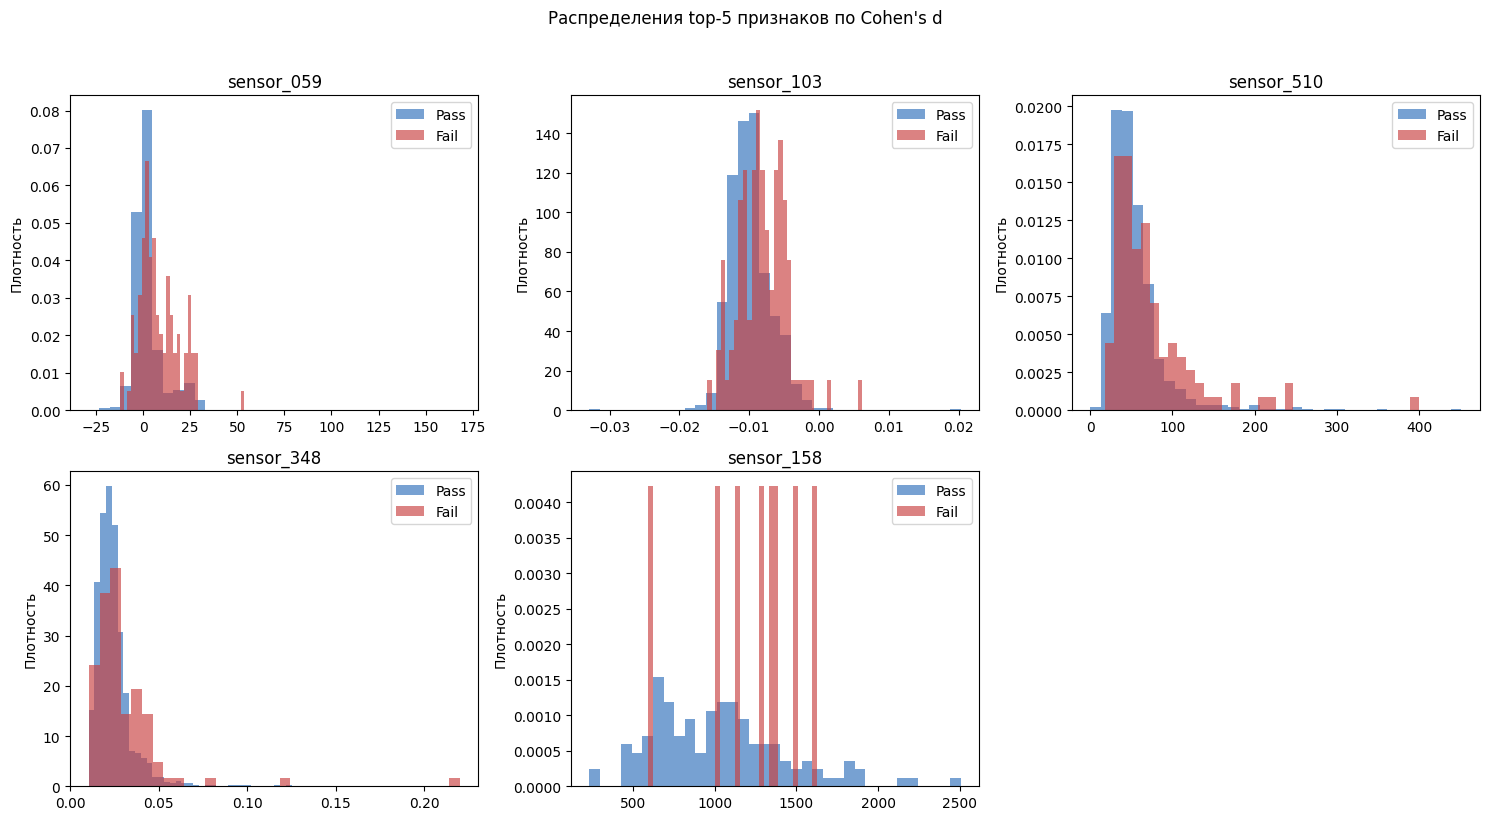

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, feature in zip(axes, top5_features):
    pass_values = X_raw.loc[y == 0, feature].dropna()
    fail_values = X_raw.loc[y == 1, feature].dropna()
    ax.hist(pass_values, bins=35, alpha=0.65, density=True, label="Pass", color="#2f6fbb")
    ax.hist(fail_values, bins=35, alpha=0.65, density=True, label="Fail", color="#c93f3f")
    ax.set_title(feature)
    ax.set_ylabel("Плотность")
    ax.legend()

axes[-1].axis("off")
plt.suptitle("Распределения top-5 признаков по Cohen's d", y=1.02)
plt.tight_layout()
plt.show()


C:\Users\shega\AppData\Local\Temp\ipykernel_11040\2991395320.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Pass", "Fail"], showfliers=False)
C:\Users\shega\AppData\Local\Temp\ipykernel_11040\2991395320.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Pass", "Fail"], showfliers=False)
C:\Users\shega\AppData\Local\Temp\ipykernel_11040\2991395320.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Pass", "Fail"], showfliers=False)
C:\Users\shega\AppData\Local\Temp\ipykernel_11040\2991395320.py:4: MatplotlibDeprecationWarning: The 'labe

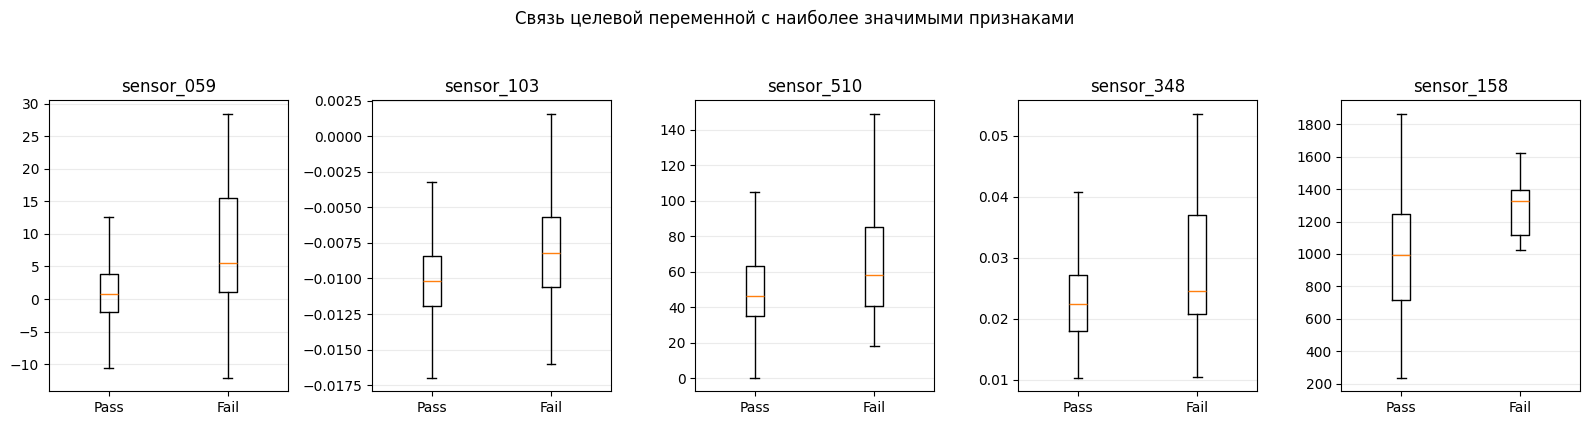

In [9]:
fig, axes = plt.subplots(1, len(top5_features), figsize=(16, 4), sharey=False)
for ax, feature in zip(axes, top5_features):
    data = [X_raw.loc[y == 0, feature].dropna(), X_raw.loc[y == 1, feature].dropna()]
    ax.boxplot(data, labels=["Pass", "Fail"], showfliers=False)
    ax.set_title(feature)
    ax.grid(axis="y", alpha=0.25)
plt.suptitle("Связь целевой переменной с наиболее значимыми признаками", y=1.05)
plt.tight_layout()
plt.show()


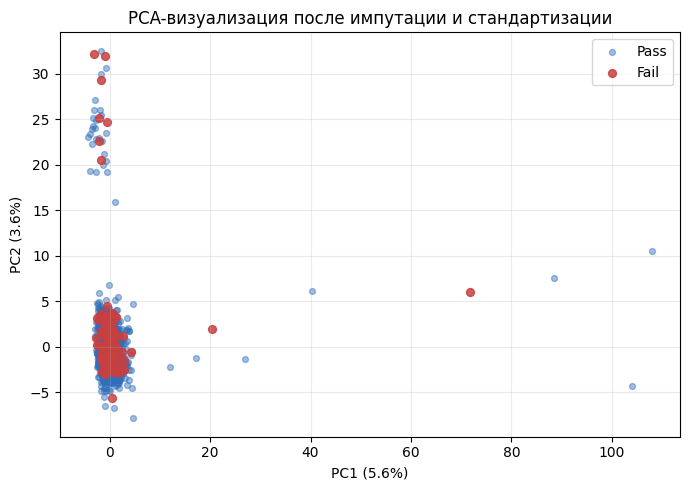

In [10]:
pca_pipeline = Pipeline([
    ("variance", VarianceThreshold(threshold=0.0)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])

X_pca = pca_pipeline.fit_transform(X_raw)
pca = pca_pipeline.named_steps["pca"]

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], s=18, alpha=0.45, label="Pass", color="#2f6fbb")
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], s=32, alpha=0.85, label="Fail", color="#c93f3f")
plt.title("PCA-визуализация после импутации и стандартизации")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Гипотезы машинного обучения

| Гипотеза | Модель | Почему подходит | Основные гиперпараметры и диапазоны |
|---|---|---|---|
| H1 | Logistic Regression | Сильный интерпретируемый baseline для малой выборки и высокой размерности; L1 может занулять лишние признаки | `C: 0.01..10`, `penalty: l1/l2`, `select__k: 20..120` |
| H2 | Gaussian Naive Bayes | Быстрая вероятностная модель, полезная как простая baseline после отбора признаков | `var_smoothing: 1e-9..1e-3`, `select__k: 10..80` |
| H3 | KNN | Проверяет гипотезу локального сходства объектов после нормализации | `n_neighbors: 3..25`, `weights: uniform/distance`, `select__k: 10..40` |
| H4 | Decision Tree | Дает пороговые диагностические правила, понятные для технологической интерпретации | `max_depth: 2..5`, `min_samples_leaf: 10..40`, `select__k: 10..80` |
| H5 | Random Forest | Проверяет устойчивые нелинейные зависимости и взаимодействия признаков; снижает дисперсию одиночного дерева | `max_depth: 3/5/None`, `min_samples_leaf: 5/20`, `max_features: sqrt/0.25`, `select__k: 40..120` |
| H6 | CatBoostClassifier | Более тяжелый градиентный бустинг по деревьям; часто хорошо работает на табличных данных, ловит нелинейности и взаимодействия признаков | `iterations: 300..600`, `depth: 3..6`, `learning_rate: 0.03..0.10`, `l2_leaf_reg: 1..10`, `select__k: 40..120` |

Основной критерий выбора - `balanced_accuracy` или, эквивалентно, минимизация `BER = 1 - balanced_accuracy`. Для производственной задачи также обязательно смотреть `recall_fail`: сколько дефектных единиц модель успевает поймать.

Для H6 нужен пакет `catboost`. Если он не установлен, notebook не сломается: CatBoost будет пропущен, а в выводе появится команда установки `pip install catboost`.

In [11]:
class SensorFeatureEngineer(BaseEstimator, TransformerMixin):
    """Add missingness indicators and robust row-level deviation indicators."""

    def fit(self, X, y=None):
        x = np.asarray(X, dtype=float)
        self.n_features_in_ = x.shape[1]
        medians = np.nanmedian(x, axis=0)
        medians = np.where(np.isfinite(medians), medians, 0.0)
        imputed = np.where(np.isnan(x), medians, x)
        means = imputed.mean(axis=0)
        stds = imputed.std(axis=0)
        stds = np.where(stds > 1e-12, stds, 1.0)
        self.medians_ = medians
        self.means_ = means
        self.stds_ = stds
        return self

    def transform(self, X):
        x = np.asarray(X, dtype=float)
        missing_count = np.isnan(x).sum(axis=1).reshape(-1, 1)
        missing_rate = missing_count / max(1, x.shape[1])
        imputed = np.where(np.isnan(x), self.medians_, x)
        z = (imputed - self.means_) / self.stds_
        mean_abs_z = np.mean(np.abs(z), axis=1).reshape(-1, 1)
        max_abs_z = np.max(np.abs(z), axis=1).reshape(-1, 1)
        return np.hstack([x, missing_count, missing_rate, mean_abs_z, max_abs_z])

class MissingRateDropper(BaseEstimator, TransformerMixin):
    """Drop columns with too many missing values in the current training fold."""

    def __init__(self, max_missing_rate=0.50):
        self.max_missing_rate = max_missing_rate

    def fit(self, X, y=None):
        x = np.asarray(X, dtype=float)
        self.keep_mask_ = np.isnan(x).mean(axis=0) <= self.max_missing_rate
        if not np.any(self.keep_mask_):
            raise ValueError("All features were removed by MissingRateDropper.")
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.keep_mask_]

def make_common_pipeline(model):
    return Pipeline([
        ("engineer", SensorFeatureEngineer()),
        ("drop_missing", MissingRateDropper(max_missing_rate=0.50)),
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=40)),
        ("model", model),
    ])


In [12]:
# Three-way split: train / validation / test.
# Train is used for fitting and cross-validation during hyperparameter search.
# Validation is used for threshold selection and sanity-checking the selected model.
# Test is used only once for the final unbiased estimate.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame([
    {"split": "train", "n": len(y_train), "fail": int(y_train.sum()), "fail_rate": y_train.mean()},
    {"split": "validation", "n": len(y_validation), "fail": int(y_validation.sum()), "fail_rate": y_validation.mean()},
    {"split": "test", "n": len(y_test), "fail": int(y_test.sum()), "fail_rate": y_test.mean()},
])
display(split_summary)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "recall_fail": make_scorer(recall_score, pos_label=1, zero_division=0),
    "precision_fail": make_scorer(precision_score, pos_label=1, zero_division=0),
    "f1_fail": make_scorer(f1_score, pos_label=1, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

experiments = {
    "logistic_regression": {
        "pipeline": make_common_pipeline(LogisticRegression(
            solver="liblinear", class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE
        )),
        "params": {
            "select__k": [20, 40, 80, 120],
            "model__C": [0.01, 0.1, 1.0, 10.0],
            "model__penalty": ["l1", "l2"],
        },
    },
    "gaussian_naive_bayes": {
        "pipeline": make_common_pipeline(GaussianNB()),
        "params": {"select__k": [10, 20, 40, 80], "model__var_smoothing": [1e-9, 1e-6, 1e-3]},
    },
    "knn": {
        "pipeline": make_common_pipeline(KNeighborsClassifier()),
        "params": {
            "select__k": [10, 20, 40],
            "model__n_neighbors": [3, 5, 11, 25],
            "model__weights": ["uniform", "distance"],
        },
    },
    "decision_tree": {
        "pipeline": make_common_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
        "params": {
            "select__k": [10, 20, 40, 80],
            "model__max_depth": [2, 3, 4, 5],
            "model__min_samples_leaf": [10, 20, 40],
        },
    },
    "random_forest": {
        "pipeline": make_common_pipeline(RandomForestClassifier(
            n_estimators=300, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
        )),
        "params": {
            "select__k": [40, 80, 120],
            "model__max_depth": [3, 5, None],
            "model__min_samples_leaf": [5, 20],
            "model__max_features": ["sqrt", 0.25],
        },
    },
}

if CATBOOST_AVAILABLE:
    experiments["catboost"] = {
        "pipeline": make_common_pipeline(CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )),
        "params": {
            "select__k": [40, 80, 120],
            "model__iterations": [300, 600],
            "model__depth": [3, 5, 6],
            "model__learning_rate": [0.03, 0.10],
            "model__l2_leaf_reg": [1, 3, 10],
        },
    }
else:
    print("CatBoost не установлен. Для проверки H6 выполните: pip install catboost")

,split,n,fail,fail_rate
0,train,940,62,0.0660
1,validation,313,21,0.0671
2,test,314,21,0.0669


In [13]:
# This cell may take several minutes.
searches = {}
all_cv_rows = []

for name, config in experiments.items():
    print(f"Running {name}...")
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring=scoring,
        refit="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=0,
    )
    search.fit(X_train, y_train)
    searches[name] = search

    result = pd.DataFrame(search.cv_results_)
    result["algorithm"] = name
    result["ber"] = 1 - result["mean_test_balanced_accuracy"]
    all_cv_rows.append(result)
    print("  best balanced_accuracy:", round(search.best_score_, 4))
    print("  best params:", search.best_params_)

cv_results = pd.concat(all_cv_rows, ignore_index=True)
comparison_cols = [
    "algorithm",
    "mean_test_balanced_accuracy",
    "ber",
    "mean_test_recall_fail",
    "mean_test_precision_fail",
    "mean_test_f1_fail",
    "mean_test_roc_auc",
    "mean_test_average_precision",
    "params",
]
cv_results.sort_values("mean_test_balanced_accuracy", ascending=False)[comparison_cols].head(15)


Running logistic_regression...
  best balanced_accuracy: 0.6564
  best params: {'model__C': 0.01, 'model__penalty': 'l2', 'select__k': 20}
Running gaussian_naive_bayes...
  best balanced_accuracy: 0.5594
  best params: {'model__var_smoothing': 1e-09, 'select__k': 80}
Running knn...
  best balanced_accuracy: 0.5098
  best params: {'model__n_neighbors': 3, 'model__weights': 'uniform', 'select__k': 20}
Running decision_tree...
  best balanced_accuracy: 0.653
  best params: {'model__max_depth': 2, 'model__min_samples_leaf': 10, 'select__k': 20}
Running random_forest...
  best balanced_accuracy: 0.6346
  best params: {'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'select__k': 40}
Running catboost...
  best balanced_accuracy: 0.5844
  best params: {'model__depth': 3, 'model__iterations': 300, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.03, 'select__k': 40}


,algorithm,mean_test_balanced_accuracy,ber,mean_test_recall_fail,mean_test_precision_fail,mean_test_f1_fail,mean_test_roc_auc,mean_test_average_precision,params
4,logistic_regression,0.6564,0.3436,0.6077,0.1276,0.2105,0.6941,0.1553,"{'model__C': 0.01, 'model__penalty': 'l2', 'se..."
73,decision_tree,0.6530,0.3470,0.5590,0.1399,0.2178,0.6607,0.1171,"{'model__max_depth': 2, 'model__min_samples_le..."
69,decision_tree,0.6530,0.3470,0.5590,0.1399,0.2178,0.6607,0.1171,"{'model__max_depth': 2, 'model__min_samples_le..."
5,logistic_regression,0.6497,0.3503,0.6103,0.1222,0.2034,0.7077,0.1480,"{'model__C': 0.01, 'model__penalty': 'l2', 'se..."
9,logistic_regression,0.6363,0.3637,0.5333,0.1267,0.2045,0.6907,0.1452,"{'model__C': 0.1, 'model__penalty': 'l1', 'sel..."
119,random_forest,0.6346,0.3654,0.3705,0.2025,0.2605,0.7211,0.1850,"{'model__max_depth': 3, 'model__max_features':..."
125,random_forest,0.6305,0.3695,0.3692,0.1898,0.2494,0.7130,0.1752,"{'model__max_depth': 3, 'model__max_features':..."
6,logistic_regression,0.6302,0.3698,0.5769,0.1150,0.1915,0.6927,0.1660,"{'model__C': 0.01, 'model__penalty': 'l2', 'se..."
116,random_forest,0.6272,0.3728,0.3397,0.2181,0.2628,0.7167,0.1792,"{'model__max_depth': 3, 'model__max_features':..."
122,random_forest,0.6225,0.3775,0.3385,0.1989,0.2476,0.7077,0.1779,"{'model__max_depth': 3, 'model__max_features':..."


In [14]:
best_by_algorithm = (
    cv_results.sort_values("mean_test_balanced_accuracy", ascending=False)
    .groupby("algorithm", as_index=False)
    .head(1)
    .sort_values("mean_test_balanced_accuracy", ascending=False)
)
best_by_algorithm[comparison_cols]


,algorithm,mean_test_balanced_accuracy,ber,mean_test_recall_fail,mean_test_precision_fail,mean_test_f1_fail,mean_test_roc_auc,mean_test_average_precision,params
4,logistic_regression,0.6564,0.3436,0.6077,0.1276,0.2105,0.6941,0.1553,"{'model__C': 0.01, 'model__penalty': 'l2', 'se..."
73,decision_tree,0.6530,0.3470,0.5590,0.1399,0.2178,0.6607,0.1171,"{'model__max_depth': 2, 'model__min_samples_le..."
119,random_forest,0.6346,0.3654,0.3705,0.2025,0.2605,0.7211,0.1850,"{'model__max_depth': 3, 'model__max_features':..."
158,catboost,0.5844,0.4156,0.2577,0.1655,0.1993,0.7005,0.1867,"{'model__depth': 3, 'model__iterations': 300, ..."
39,gaussian_naive_bayes,0.5594,0.4406,0.1756,0.1933,0.1798,0.6919,0.1585,"{'model__var_smoothing': 1e-06, 'select__k': 80}"
45,knn,0.5098,0.4902,0.0333,0.1500,0.0536,0.5270,0.0826,"{'model__n_neighbors': 3, 'model__weights': 'u..."


In [15]:
best_row = cv_results.sort_values("mean_test_balanced_accuracy", ascending=False).iloc[0]
best_algorithm = best_row["algorithm"]
best_search = searches[best_algorithm]
best_model = best_search.best_estimator_

print("Best algorithm:", best_algorithm)
print("Best CV balanced accuracy:", best_search.best_score_)
print("Best BER:", 1 - best_search.best_score_)
print("Best params:", best_search.best_params_)


Best algorithm: logistic_regression
Best CV balanced accuracy: 0.6563558941058941
Best BER: 0.3436441058941059
Best params: {'model__C': 0.01, 'model__penalty': 'l2', 'select__k': 20}


## 5. Настройка порога, validation и финальная test-проверка

Для дисбалансированных данных недостаточно выбрать модель: стандартный порог `0.5` может быть неудачным. Теперь выборка делится на три части:

- `train` - обучение моделей и cross-validation для подбора гиперпараметров;
- `validation` - выбор порога вероятности для класса `Fail` и промежуточная проверка выбранной модели;
- `test` - финальная оценка, которая выполняется один раз после выбора модели и порога.

Такой порядок уменьшает риск подгонки под test-выборку.

In [16]:
best_model.fit(X_train, y_train)
validation_proba = best_model.predict_proba(X_validation)[:, 1]

threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 91):
    pred = (validation_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(y_validation, pred),
        "ber": 1 - balanced_accuracy_score(y_validation, pred),
        "recall_fail": recall_score(y_validation, pred, pos_label=1, zero_division=0),
        "precision_fail": precision_score(y_validation, pred, pos_label=1, zero_division=0),
        "f1_fail": f1_score(y_validation, pred, pos_label=1, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_rows)

# Primary criterion: balanced accuracy. Ties are resolved by Recall Fail and then F1 Fail.
best_threshold_row = threshold_table.sort_values(
    ["balanced_accuracy", "recall_fail", "f1_fail"], ascending=False
).iloc[0]
best_threshold = float(best_threshold_row["threshold"])
best_threshold_row

threshold            0.4200
balanced_accuracy    0.6429
ber                  0.3571
recall_fail          0.7619
precision_fail       0.1032
f1_fail              0.1818
Name: 37, dtype: float64

In [17]:
# Final fit on train + validation after model and threshold have been selected.
# The test split is touched only here.
X_train_validation = pd.concat([X_train, X_validation], axis=0)
y_train_validation = pd.concat([y_train, y_validation], axis=0)

best_model.fit(X_train_validation, y_train_validation)
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
    "ber": 1 - balanced_accuracy_score(y_test, test_pred),
    "recall_fail": recall_score(y_test, test_pred, pos_label=1, zero_division=0),
    "precision_fail": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
    "f1_fail": f1_score(y_test, test_pred, pos_label=1, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "average_precision": average_precision_score(y_test, test_proba),
}

print(json.dumps(test_metrics, indent=2, ensure_ascii=False))
print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, test_pred))
print("\nClassification report:")
print(classification_report(y_test, test_pred, target_names=["Pass", "Fail"], zero_division=0))

{
  "accuracy": 0.5191082802547771,
  "balanced_accuracy": 0.6539086624410857,
  "ber": 0.3460913375589143,
  "recall_fail": 0.8095238095238095,
  "precision_fail": 0.10365853658536585,
  "f1_fail": 0.1837837837837838,
  "roc_auc": 0.7167235494880546,
  "average_precision": 0.21758560292786805
}

Confusion matrix [[TN, FP], [FN, TP]]:
[[146 147]
 [  4  17]]

Classification report:
              precision    recall  f1-score   support

        Pass       0.97      0.50      0.66       293
        Fail       0.10      0.81      0.18        21

    accuracy                           0.52       314
   macro avg       0.54      0.65      0.42       314
weighted avg       0.92      0.52      0.63       314



In [18]:
test_comparison = pd.DataFrame([
    {"strategy": "always_pass_test", **binary_metrics(y_test, np.zeros_like(y_test))},
    {"strategy": f"best_model_{best_algorithm}", **binary_metrics(y_test, test_pred)},
])
test_comparison

,strategy,accuracy,balanced_accuracy,ber,recall_fail,precision_fail,f1_fail
0,always_pass_test,0.9331,0.5000,0.5000,0.0000,0.0000,0.0000
1,best_model_logistic_regression,0.5191,0.6539,0.3461,0.8095,0.1037,0.1838


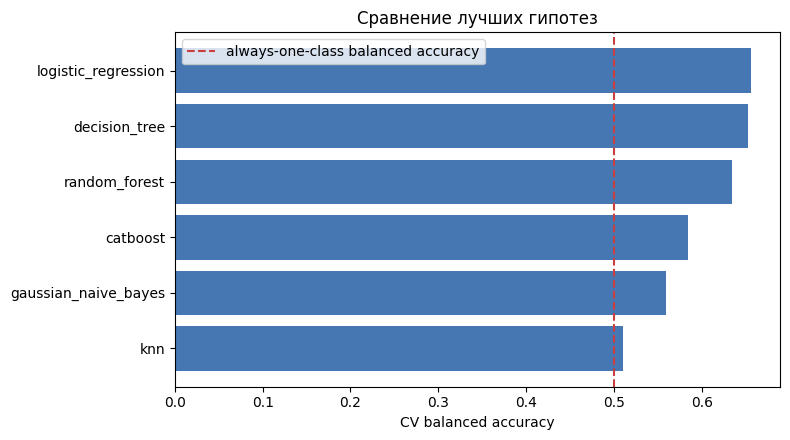

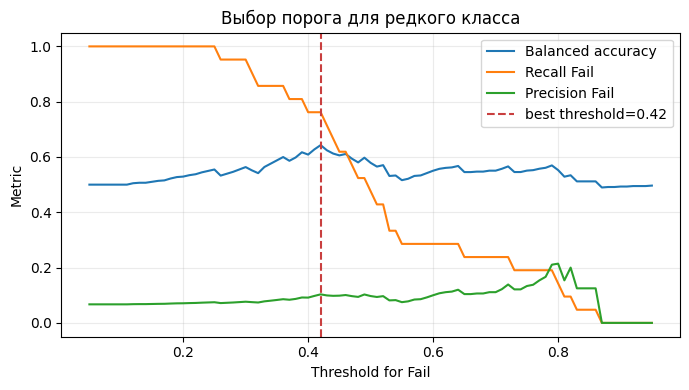

In [19]:
plot_table = best_by_algorithm.sort_values("mean_test_balanced_accuracy", ascending=True)
plt.figure(figsize=(8, 4.5))
plt.barh(plot_table["algorithm"], plot_table["mean_test_balanced_accuracy"], color="#4777b3")
plt.axvline(0.5, color="#c93f3f", linestyle="--", label="always-one-class balanced accuracy")
plt.xlabel("CV balanced accuracy")
plt.title("Сравнение лучших гипотез")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(threshold_table["threshold"], threshold_table["balanced_accuracy"], label="Balanced accuracy")
plt.plot(threshold_table["threshold"], threshold_table["recall_fail"], label="Recall Fail")
plt.plot(threshold_table["threshold"], threshold_table["precision_fail"], label="Precision Fail")
plt.axvline(best_threshold, color="#c93f3f", linestyle="--", label=f"best threshold={best_threshold:.2f}")
plt.xlabel("Threshold for Fail")
plt.ylabel("Metric")
plt.title("Выбор порога для редкого класса")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Итоговые выводы

1. В анализ следует включать все записи и все сенсорные признаки из `secom.data`, потому что признаки анонимизированы и без технологического паспорта преждевременное исключение сенсоров может убрать полезный сигнал. Метку и timestamp берем из `secom_labels.data`.
2. Главная особенность данных - сильный дисбаланс: `Fail` составляет примерно 6-7% наблюдений. Правило `always Pass` дает около 93.4% accuracy, но `Recall Fail = 0` и `Balanced Accuracy = 0.5`; поэтому основная метрика - `balanced_accuracy` / `BER`, а не обычная accuracy.
3. Обязательные этапы preprocessing: проверка консистентности, обработка пропусков внутри pipeline, удаление константных признаков, стандартизация и стратифицированное разделение на train / validation / test.
4. Feature engineering должен быть скромным и устойчивым: row-level missingness, интегральные z-score показатели, supervised отбор top-K признаков. PCA полезна для разведочной визуализации, но хуже для интерпретации итоговой модели.
5. Для решения задачи разумно сравнить линейную модель, наивный Байес, KNN, одиночное дерево, Random Forest и CatBoost. Веса классов и настройка порога вероятности критичны, потому что иначе модель может выглядеть хорошей по accuracy, но пропускать почти все `Fail`.
6. Сравнение с `always Pass` обязательно нужно показывать в отчете: если бизнес-цель - только максимальная accuracy, тривиальная стратегия выигрывает; если цель - обнаруживать брак, модель выбирается по BER, recall/F1 для `Fail`, PR-AUC или стоимости ошибок.
7. CatBoost добавлен как H6: это более тяжелая модель градиентного бустинга для проверки нелинейных зависимостей и взаимодействий сенсоров. Если пакет `catboost` не установлен, соответствующая гипотеза пропускается без падения notebook.
8. Финальный выбор модели следует делать по cross-validation на train-части, порог подбирать на validation, а итоговые метрики приводить на test: `Balanced Accuracy`, `BER`, `Recall Fail`, `Precision Fail`, `F1 Fail`, `ROC AUC`, `Average Precision` и confusion matrix.
